In [1]:
# --- Step 1: Setup & Imports ---
import torch
import numpy as np
import h5py
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from scipy.interpolate import interp1d

# include .. in the path
import sys
import os

sys.path.insert(0, "..")


# Import your custom classes
from gpy_dla_detection.learn_qso_model import GPTrainingSetLoader, SpectrumProcessor, GaussianProcessModel, Trainer
from gpy_dla_detection.objective import objective
from gpy_dla_detection.voigt import transition_wavelengths as all_transition_wavelengths
from gpy_dla_detection.voigt import oscillator_strengths as all_oscillator_strengths
from gpy_dla_detection.learn_qso_model import compute_pca

import torch

# Select device (CUDA if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print(torch.cuda.is_available())  # Should return True if GPU is enabled
print(torch.cuda.device_count())  # Number of GPUs available
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))  # GPU model name

Using device: cuda
Using device: cuda
True
1
NVIDIA A100-PCIE-40GB


In [2]:
import h5py

with h5py.File("../learnlogs/model_epoch_799.h5", "r") as f:
    print(f.keys())
    log_tau_0_history = f["log_tau_0_history"][:]
    log_c_0_history = f["log_c_0_history"][:]
    loss_history = f["loss_history"][:]
    log_omega = f["log_omega"][:]
    rest_wavelengths = f["rest_wavelengths"][:]
    mu = f["mu"][:]
    log_beta_history = f["log_beta_history"][:]
    M = f["M"][:]
    initial_M = f["initial_M"][:]
    print(f["log_tau_0"].ndim)

<KeysViewHDF5 ['M', 'initial_M', 'initial_beta', 'initial_log_c_0', 'initial_log_omega', 'initial_log_tau_0', 'log_beta', 'log_beta_history', 'log_c_0', 'log_c_0_history', 'log_omega', 'log_tau_0', 'log_tau_0_history', 'loss_history', 'max_noise_variance', 'mu', 'rest_wavelengths']>
0


In [2]:
import h5py

with h5py.File("../learnlogs_london/model_epoch_199.h5", "r") as f:
    print(f.keys())
    log_tau_0_history = f["log_tau_0_history"][:]
    log_c_0_history = f["log_c_0_history"][:]
    loss_history = f["loss_history"][:]
    log_omega = f["log_omega"][:]
    rest_wavelengths = f["rest_wavelengths"][:]
    mu = f["mu"][:]
    log_beta_history = f["log_beta_history"][:]
    M = f["M"][:]
    initial_M = f["initial_M"][:]
    print(f["log_tau_0"].ndim)

<KeysViewHDF5 ['M', 'initial_M', 'initial_beta', 'initial_log_c_0', 'initial_log_omega', 'initial_log_tau_0', 'log_beta', 'log_beta_history', 'log_c_0', 'log_c_0_history', 'log_omega', 'log_tau_0', 'log_tau_0_history', 'loss_history', 'max_noise_variance', 'mu', 'rest_wavelengths']>
0


In [3]:
np.diag(np.matmul(M, M.T))

array([0.6129022 , 0.60264796, 0.61304504, ..., 0.00456302, 0.00432213,
       0.00385339], dtype=float32)

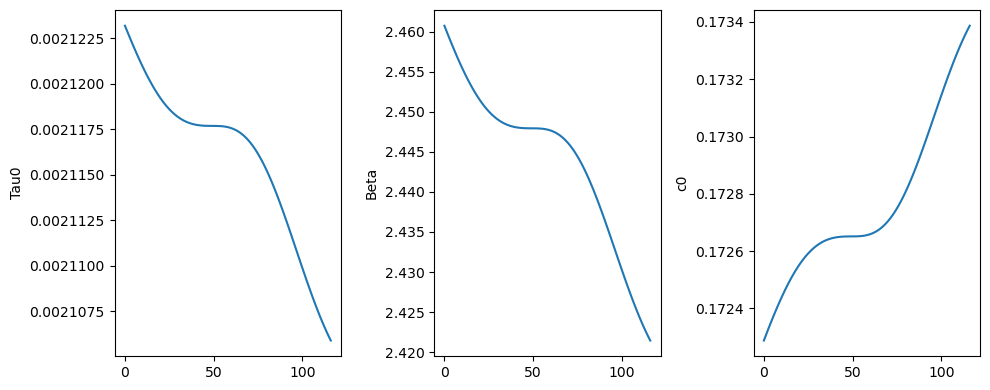

In [4]:
np.exp(log_beta_history), np.exp(log_c_0_history), np.exp(log_tau_0_history)

fig,ax= plt.subplots(1,3, figsize=(10,4))

ax[0].plot(np.exp(log_tau_0_history))
ax[0].set_ylabel("Tau0")
ax[1].plot(np.exp(log_beta_history))
ax[1].set_ylabel("Beta")
ax[2].plot(np.exp(log_c_0_history))
ax[2].set_ylabel("c0")

fig.tight_layout()

(-1.0, 5.0)

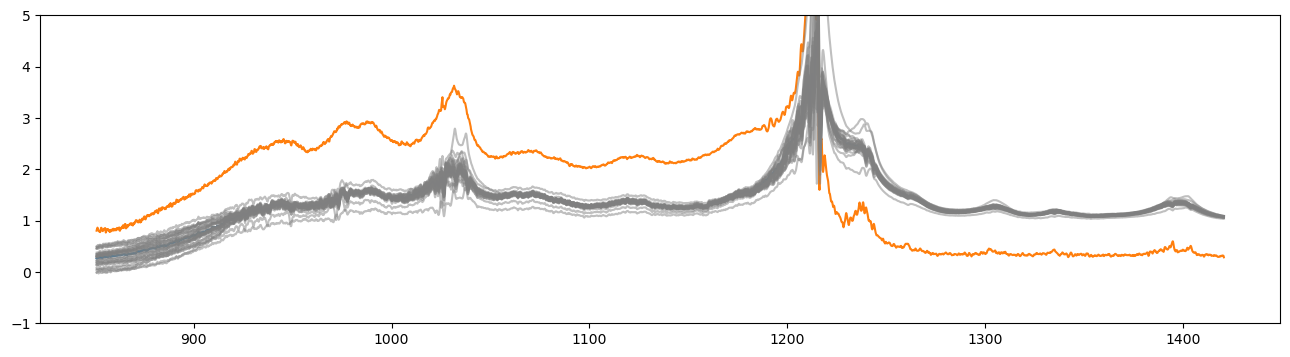

In [5]:
plt.figure(figsize=(16,4))
plt.plot(rest_wavelengths, mu)
plt.plot(rest_wavelengths, np.exp(log_omega))
for i in range(30):
    plt.plot(rest_wavelengths, mu +  M[:,i], color="grey", alpha=0.5)
# plt.plot(rest_wavelengths, np.diag(np.matmul(M, M.T)))
plt.ylim(-1 ,5)

Text(0.5, 0, 'Epoch')

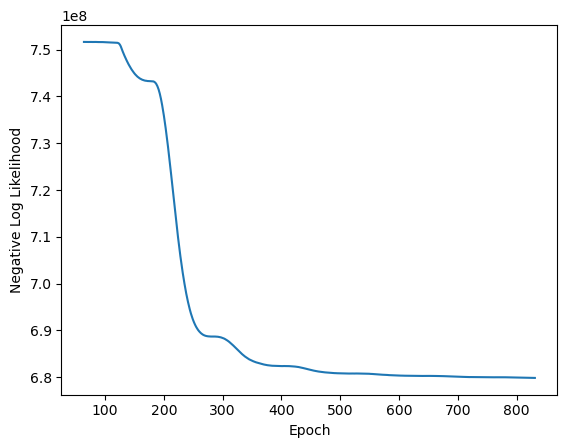

In [6]:
plt.plot(np.arange(len(loss_history))[64:], loss_history[64:])
plt.ylabel("Negative Log Likelihood")
plt.xlabel("Epoch")

Text(0, 0.5, 'Eigenspectrum Index')

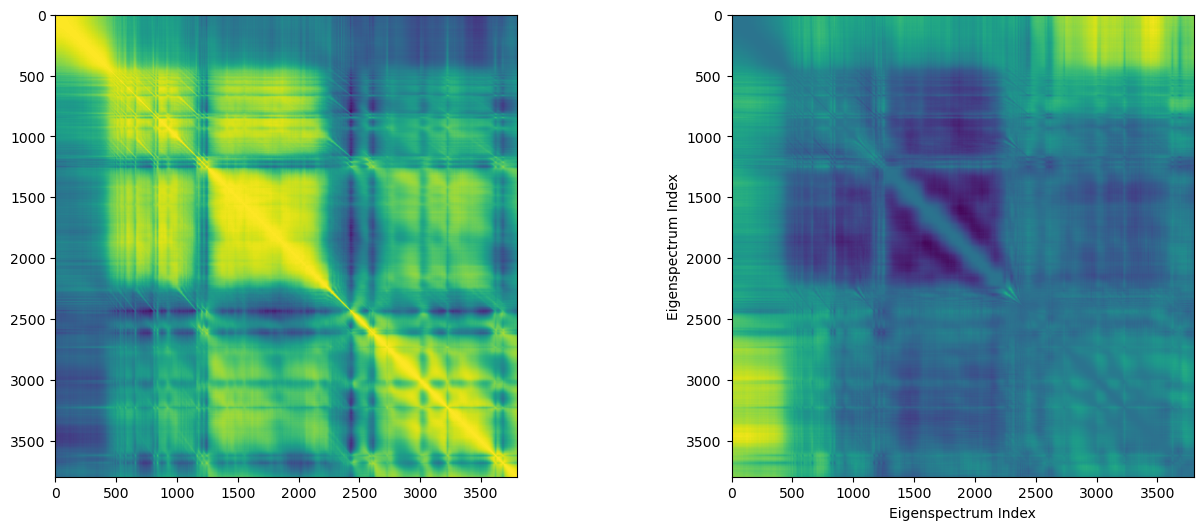

In [7]:
K = np.dot(M, M.T)
C1 = K / np.sqrt(np.outer(np.diag(K), np.diag(K)))

fig,ax=plt.subplots(1,2, figsize=(16, 6))
ax[0].imshow(C1, cmap="viridis")
K = np.dot(initial_M, initial_M.T)
C2 = K / np.sqrt(np.outer(np.diag(K), np.diag(K)))
ax[1].imshow(C2 - C1, cmap="viridis")
# fig.colorbar()
# plt.title(f"Correlation Matrix of Eigenspectra (Epoch {epoch})")
plt.xlabel("Eigenspectrum Index")
plt.ylabel("Eigenspectrum Index")


In [ ]:

# --- Step 2: Load Quasar Spectra using QSOLoader ---
catalog_file = "/pscratch/sd/j/jibancat/desi_gpy_dla_detection/data/loa/gp_trainset_loa.fits"
preloaded_file = "/pscratch/sd/j/jibancat/preload-loa-gpdla-20250202/gp_interp_trainset.h5"

qso_loader = GPTrainingSetLoader(catalog_file, preloaded_file, z_range=(2.5, 4.25), min_snr=0.0, max_spectra=200000)
fluxes, wavelengths, noise_variances, z_qsos = qso_loader.load_data()

print(f"Loaded {len(fluxes)} spectra.")


Loaded 509412 nonBAL-nonDLA etc QSOs from /pscratch/sd/j/jibancat/desi_gpy_dla_detection/data/loa/gp_trainset_loa.fits
[Warning] Likely not correct keys preloaded file: "Unable to synchronously open object (object 'tidlist' doesn't exist)"


In [ ]:
idx = 100
plt.figure(figsize=(16, 4))
plt.plot(wavelengths[idx], fluxes[idx])

In [ ]:
import torch
import numpy as np

# --- Step 1: Initialize Spectrum Processor ---
max_noise_variance = 9.0
spectrum_processor = SpectrumProcessor(min_lambda=850.90, max_lambda=1420.60, num_pixels=3798, 
                                       norm_min_lambda=900, norm_max_lambda=1200, max_noise_variance=max_noise_variance)

# # --- Step 2: Normalize Spectra ---
# norm_fluxes, norm_noise_variances, all_rest_wavelengths = spectrum_processor.normalize_spectra(
#     wavelengths, fluxes, noise_variances, z_qsos=z_qsos
# )

# --- Step 3: Mask Noisy Pixels BEFORE Interpolation ---
masked_fluxes, masked_noise_variances = spectrum_processor.mask_noisy_pixels(fluxes, noise_variances)

# --- Step 4: Interpolate onto Common Rest-Frame Grid ---
fluxes_interpolated, noise_variances_interpolated, all_rest_wavelengths = spectrum_processor.interpolate_spectra(
    wavelengths, masked_fluxes, masked_noise_variances
)

# # --- Step 5: Fill in NaNs with Median BEFORE Deforesting ---
# fluxes_interpolated = spectrum_processor.fill_nan_with_median(fluxes_interpolated)

# --- Step 6: Deforest the Spectra ---
deforest_fluxes, deforest_noise_variance = spectrum_processor.de_forest_spectra(
    all_rest_wavelengths, fluxes_interpolated, noise_variances_interpolated, z_qsos=z_qsos
)

# --- Step 7: Center the Flux for GP Training ---
centered_fluxes, mu = spectrum_processor.center_fluxes(deforest_fluxes, deforest_noise_variance)

# --- Step 4: Remove Spectra with Any NaNs ---
centered_fluxes, deforest_noise_variance, all_rest_wavelengths, z_qsos = spectrum_processor.remove_nan_spectra(
    centered_fluxes, deforest_noise_variance, all_rest_wavelengths, z_qsos
)

# --- Step 8: Convert to Single NumPy Arrays Before Tensor Conversion ---
fluxes_np = np.array(centered_fluxes, dtype=np.float32)
noise_variances_np = np.array(deforest_noise_variance, dtype=np.float32)
z_qsos_np = np.array(z_qsos, dtype=np.float32)[:, None]  # Ensure correct shape

# --- Step 9: Convert to Torch Tensors ---
all_rest_wavelengths_tensor = torch.from_numpy(all_rest_wavelengths).to(device)
fluxes_tensor = torch.from_numpy(fluxes_np).to(device)
noise_variances_tensor = torch.from_numpy(noise_variances_np).to(device)
z_qsos_tensor = torch.from_numpy(z_qsos_np).to(device)

In [ ]:
plt.figure(figsize=(16,4))
plt.plot(all_rest_wavelengths[0], mu)

In [ ]:
# visualize the spectra
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.plot(spectrum_processor.rest_wavelengths, fluxes_tensor[i].cpu().numpy())
plt.xlabel("Wavelength (Angstroms)")
plt.ylabel("Normalized Flux")
plt.title("Example Quasar Spectrum")
plt.show()

In [ ]:
# --- Step 4: Train the GP Model ---
num_pixels = 3798  # Match rest-wavelength grid
num_pca_components = 30
use_template = False

# compute PCA components and eigenspectra
pca_fluxes = spectrum_processor.fill_nan_with_median(fluxes_tensor.cpu().numpy().copy())
coefficients, latent = compute_pca(pca_fluxes, num_pca_components)
initial_M = coefficients[:, :num_pca_components] * np.sqrt(latent[:num_pca_components])  # Broadcasting happens automatically

if use_template:
    print("Using template model ...")

    temp_model = np.load("../data/temp_model/QSO-HIZv1.1_RR.npz") # hard-coded path
    temp_pca = temp_model["PCA_COMP"] # normalized PCA components, centered 0
    temp_wave = 10**temp_model["LOGLAM"] # rest-frame wavelength

    # model rest-frame wavelength
    model_wave = all_rest_wavelengths_tensor[0].cpu().numpy()

    # interpolate PCA components
    temp_pca_interp = np.zeros((temp_pca.shape[0], len(model_wave)))

    for i in range(temp_pca.shape[0]):
        f = interp1d(temp_wave, temp_pca[i], kind="linear", fill_value="extrapolate")
        temp_pca_interp[i, :] = f(model_wave)

    # Replace the last few PCA components with the template PCA components
    coefficients, latent = compute_pca(fluxes_tensor, num_pca_components)
    # Compute initial M using PCA coefficients and square root of eigenvalues
    k = num_pca_components
    # Shape of coefficients: (num_pixels, num_pca_components)
    initial_M = coefficients[:, :k] * np.sqrt(latent[:k])  # Broadcasting happens automatically
    initial_M[:, -temp_pca_interp.shape[0]:] = temp_pca_interp.T



In [ ]:
plt.figure(figsize=(16,4))
plt.plot(all_rest_wavelengths[0], initial_M[:, 0])
plt.plot(all_rest_wavelengths[0], initial_M[:, 1])
plt.plot(all_rest_wavelengths[0], initial_M[:, 2])
plt.plot(all_rest_wavelengths[0], initial_M[:, 3])

In [ ]:
M = initial_M
# make the covariance
K = np.dot(M, M.T)
# make the correlation matrix
C = K / np.sqrt(np.outer(np.diag(K), np.diag(K)))

# plot the correlation matrix
plt.figure(figsize=(8, 6))
plt.imshow(C, cmap='viridis')
plt.colorbar()
plt.title("Correlation Matrix of Eigenspectra")
plt.xlabel("Eigenspectrum Index")
plt.ylabel("Eigenspectrum Index")
plt.show()

In [ ]:
from gpy_dla_detection.voigt import transition_wavelengths as all_transition_wavelengths
from gpy_dla_detection.voigt import oscillator_strengths as all_oscillator_strengths

min_lambda=850.90
max_lambda=1420.60
num_pixels=3798

# Check for multiple GPUs and wrap model with DataParallel
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GaussianProcessModel(num_pixels, num_pca_components, centered_fluxes, mu=mu, max_noise_variance=max_noise_variance, 
                             min_lambda=min_lambda, max_lambda=max_lambda).to(device)

model.rest_wavelengths = model.rest_wavelengths.to(device)

all_transition_wavelengths = torch.tensor(all_transition_wavelengths, dtype=torch.float32).to(device)
all_oscillator_strengths = torch.tensor(all_oscillator_strengths, dtype=torch.float32).to(device)

lya_wavelength = all_transition_wavelengths[0] * 1e8  # Move to same device

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = torch.nn.DataParallel(model.to(device))  # ✅ Correct
    
    lya_1pz = 1 + (((1 + z_qsos_tensor.to(device)) * model.module.rest_wavelengths.unsqueeze(0)) - lya_wavelength) / lya_wavelength
else:

    lya_1pz = 1 + (((1 + z_qsos_tensor.to(device)) * model.rest_wavelengths.unsqueeze(0)) - lya_wavelength) / lya_wavelength

# Define optimizer and trainer # 40 mins for LBFGS
trainer = Trainer(
    model, optimizer_type="adam", learning_rate=0.01, batch_size=8192,
    scheduler_type="cosine", scheduler_params={"T_max": 50, "eta_min": 1e-5}
)
num_epochs = 1000

# print("Before calling objective:")
# print("all_transition_wavelengths shape:", all_transition_wavelengths.shape)  # Should be (31,)
# print("all_oscillator_strengths shape:", all_oscillator_strengths.shape)  # Should also be (31,)

# # Compute initial loss
# initial_loss = objective(model, fluxes_tensor, lya_1pz, noise_variances_tensor, 10,
#                          all_transition_wavelengths, all_oscillator_strengths, z_qsos_tensor).detach()

# print("After calling objective:")
# print("all_transition_wavelengths shape:", all_transition_wavelengths.shape)
# print("all_oscillator_strengths shape:", all_oscillator_strengths.shape)
# Train the model
trainer.train(fluxes_tensor, lya_1pz, noise_variances_tensor, z_qsos_tensor, 10, 
              all_transition_wavelengths, all_oscillator_strengths, max_epochs=num_epochs)


In [ ]:
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Device Count: {torch.cuda.device_count()}")
print(f"CUDA Current Device: {torch.cuda.current_device()}")
print(f"CUDA Device Name: {torch.cuda.get_device_name(torch.cuda.current_device())}")

In [ ]:
print("Min flux:", fluxes_tensor.min().item(), "Max flux:", fluxes_tensor.max().item())
print("Min noise:", noise_variances_tensor.min().item(), "Max noise:", noise_variances_tensor.max().item())
print("Min lya_1pz:", lya_1pz.min().item(), "Max lya_1pz:", lya_1pz.max().item())
print("Min z_qsos:", z_qsos_tensor.min().item(), "Max z_qsos:", z_qsos_tensor.max().item())

In [ ]:

# --- Step 5: Evaluate & Visualize Predictions ---
loss_history = trainer.loss_history

# Plot loss curve
plt.figure(figsize=(6, 4))
plt.plot(loss_history, label="Training Loss", color='C0')
plt.xlabel("Epoch")
plt.ylabel("Negative Log Likelihood")
plt.title("GP Training Loss Convergence")
plt.legend()
plt.show()


In [ ]:
M = model.M.detach().numpy()
# make the covariance
K = np.dot(M, M.T)
# make the correlation matrix
C = K / np.sqrt(np.outer(np.diag(K), np.diag(K)))

# plot the correlation matrix
plt.figure(figsize=(8, 6))
plt.imshow(C, cmap='viridis')
plt.colorbar()
plt.title("Correlation Matrix of Eigenspectra")
plt.xlabel("Eigenspectrum Index")
plt.ylabel("Eigenspectrum Index")
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(model.rest_wavelengths, mu, label="Mean Spectrum")
for i in range(2):
    plt.plot(model.rest_wavelengths, M[:, i] + mu, label=f"Eigenspectrum {i}")

plt.xlabel("Rest Wavelength (Angstroms)")
plt.ylabel("Normalized Flux")
plt.title("Mean Spectrum and Eigenspectra")
plt.legend()
plt.ylim(-1, 5)


In [ ]:
import matplotlib.pyplot as plt

# Select a random spectrum to test conditional GP prediction
idx = np.random.randint(0, len(fluxes_tensor))
observed_flux = fluxes_tensor[idx].unsqueeze(0)  # Shape (1, num_pixels)
observed_wavelengths = model.rest_wavelengths.unsqueeze(0)  # Shape (1, num_pixels)
noise_var = noise_variances_tensor[idx].unsqueeze(0)

# Generate a set of new wavelengths (e.g., drop 30% of original points)
mask = np.random.rand(observed_wavelengths.shape[1]) > 0.3  # Keep 70% of points
new_wavelengths = observed_wavelengths[:, mask]  # Simulate missing data

# Make GP predictions
model.eval()
with torch.no_grad():
    pred_flux, pred_var = model.predict_flux(observed_wavelengths, observed_flux, noise_var, new_wavelengths, 
                                             all_transition_wavelengths, all_oscillator_strengths, z_qsos_tensor[idx])

# Compute prediction uncertainty
pred_std = torch.sqrt(pred_var)

# --- Visualization ---
plt.figure(figsize=(8, 5))
plt.fill_between(new_wavelengths.cpu().numpy().flatten(), 
                 pred_flux.cpu().numpy().flatten() - 2 * pred_std.cpu().numpy().flatten(), 
                 pred_flux.cpu().numpy().flatten() + 2 * pred_std.cpu().numpy().flatten(), 
                 color='lightblue', alpha=0.5, label="GP 2σ confidence")

plt.plot(new_wavelengths.cpu().numpy().flatten(), pred_flux.cpu().numpy().flatten(), 'b-', label="GP Mean Prediction")
plt.scatter(observed_wavelengths.cpu().numpy().flatten(), observed_flux.cpu().numpy().flatten(), color='red', s=10, alpha=0.5, label="Observed Flux")
plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.legend()
plt.title("GP Prediction vs True Flux (Simulated Missing Data)")
plt.show()

In [ ]:
M.shape